# 02 — Real-World Solution & Video Analytics

**Deliverable 2** of the PPE Compliance Monitor capstone.

Notebook 01 ran models on still images. This one runs a **pipeline** over real site footage:
a genuine OpenCV loop — `cv2.VideoCapture` → process → `cv2.VideoWriter` — with three layers of
analysis stacked on top of tracking.

| Stage | Ultralytics API | Question it answers |
|---|---|---|
| Tracking + ledger | `model.track(persist=True)` | *Which individual worker, and for how long?* |
| Entrance gate | `solutions.ObjectCounter` | *How many people crossed onto the deck?* |
| Activity heatmap | `solutions.Heatmap` | *Where on the site does work concentrate?* |

**The point of the ledger.** A system that draws boxes on a video has given a supervisor a second
video to watch. Raw detections also flicker — a missing hard hat is seen on frame 41, lost on 42,
seen again on 43 — so logging them directly yields three "incidents" for one event. The
`ViolationLedger` in `ppe_monitor/compliance.py` debounces that into **incidents**: a violation
must persist 5 consecutive frames to open one and be clear for 15 to close it. Output is a
ranked CSV with durations and a cropped evidence photo — something a safety officer can act on.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "ppe_monitor").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from ultralytics import YOLO, solutions, settings

settings.update({
    "runs_dir": str(ROOT / "runs"),
    "datasets_dir": str(ROOT / "data" / "datasets"),
})

from ppe_monitor.compliance import ViolationLedger
from ppe_monitor.config import (
    DEFAULT_CONF,
    DEFAULT_IOU,
    ENFORCED_CLASSES,
    SITE_CLIP,
    VIOLATION_CLASSES,
    resolve_weights,
)
from ppe_monitor.video import probe, run_solution, run_tracking

OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: C:\Users\ksama\OneDrive\المستندات\projects\OpenCode\ppe-compliance-monitor


source clip : site_clip.mp4
properties  : 1280x720 @ 15.00 fps, 510 frames (34.0 s)


--- frame 300 of the source clip ---


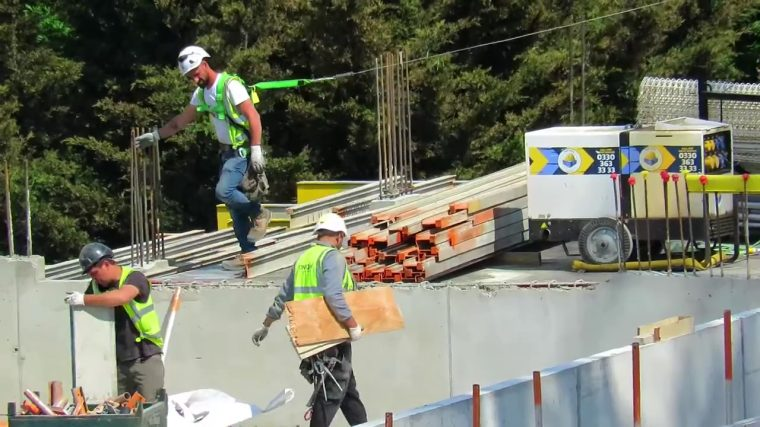

In [2]:
def show(img_bgr, max_w=760, title=None):
    """Inline preview: BGR -> RGB, downscaled, JPEG-encoded to keep the notebook small."""
    h, w = img_bgr.shape[:2]
    if w > max_w:
        img_bgr = cv2.resize(img_bgr, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)
    ok, buf = cv2.imencode(".jpg", img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 82])
    if title:
        print(title)
    display(IPyImage(data=buf.tobytes(), format="jpeg"))


def shrink(path, max_w=1000, quality=85):
    """Re-encode a written still to a size sane for version control."""
    img = cv2.imread(str(path))
    if img is None:
        return
    h, w = img.shape[:2]
    if w > max_w:
        img = cv2.resize(img, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)
    cv2.imwrite(str(path), img, [cv2.IMWRITE_JPEG_QUALITY, quality])


info = probe(SITE_CLIP)
print(f"source clip : {SITE_CLIP.name}")
print(f"properties  : {info}")

cap = cv2.VideoCapture(str(SITE_CLIP))
cap.set(cv2.CAP_PROP_POS_FRAMES, 300)
ok, sample_frame = cap.read()
cap.release()
show(sample_frame, title="--- frame 300 of the source clip ---")

## Which model?

The pipeline is written against whatever weights are available, so it runs at every stage of the
project. `resolve_weights()` returns the custom PPE model once notebook 04 has produced it, and
falls back to COCO-pretrained weights before then.

This matters for reading the results below: **COCO has no PPE classes**, so on the fallback path
the ledger can only ever report zero violations — it has nothing to detect them with. The
tracking, counting and heatmap stages are fully meaningful either way.

In [3]:
weights, is_custom = resolve_weights()
model = YOLO(weights)

# COCO's person class is 0; the custom model has no single "worker" class, so we
# let it report everything it knows.
track_classes = None if is_custom else [0]

print(f"weights      : {weights}")
print(f"custom model : {is_custom}")
print(f"classes      : {'all PPE classes' if is_custom else 'person only (COCO class 0)'}")
print(f"conf / iou   : {DEFAULT_CONF} / {DEFAULT_IOU}")
if not is_custom:
    print()
    print("NOTE: running on COCO fallback weights. Violation detection requires the")
    print("      custom model from 04_training_colab.ipynb; this notebook is re-run")
    print("      once those weights exist.")

weights      : C:\Users\ksama\OneDrive\المستندات\projects\OpenCode\ppe-compliance-monitor\models\best.pt
custom model : True
classes      : all PPE classes
conf / iou   : 0.1 / 0.5


## 1. Tracking + the violation ledger

`model.track(persist=True)` is called frame by frame inside our own OpenCV loop rather than
handing Ultralytics the whole file, because we need each frame in hand to feed the ledger and to
write evidence crops.

`persist=True` is what makes worker identity stick across frames — without it every frame starts
a fresh tracker and IDs churn, which would make "how long was this worker non-compliant?"
unanswerable.

### Two ledgers, one pass

Notebook 03 concluded that `NO-Mask` should be **detected but not enforced** on this site: an
open-air deck does not require respiratory protection, and the class only reaches 0.358 precision
anyway. That decision changes what a safety officer is actually paged about, so it is worth
seeing rather than asserting.

Both policies are scored here from the *same* tracked stream — the model runs once, and two
ledgers consume the same results. The enforced one is what ships and what writes evidence crops;
the shadow one shows what enforcing all three classes would have produced.

### Where the OpenCV loop and `model.track` actually live

`run_tracking` is a thin wrapper in [`ppe_monitor/video.py`](../ppe_monitor/video.py) rather than
an inlined loop, because the Streamlit app and this notebook must run *the same* pipeline — a
second copy would drift. The real work is this, unchanged from the source:

```python
cap = cv2.VideoCapture(str(source))                     # capture
writer = cv2.VideoWriter(str(path), fourcc, fps, size)  # write

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break
    frame_idx += 1

    result = model.track(                               # <- the tracking call
        frame, persist=True, conf=conf, iou=iou, verbose=False
    )[0]

    boxes = result.boxes
    if boxes is not None and boxes.id is not None:
        track_ids.update(boxes.id.int().tolist())

    for led in ledgers:
        led.update(frame_idx, result, frame)            # -> the violation ledger

    annotated = _plot_im(result, frame)
    writer.write(annotated)                             # process -> write
```

`persist=True` is what makes the ledger possible: without it every frame starts a fresh set of
IDs, worker 3 in frame 40 is unrelated to worker 3 in frame 41, and no violation can be
attributed to a person over time.

Two ledgers are fed from the one pass below — the enforced site policy, and a shadow ledger over
all three `NO-*` classes — so the cost of the policy decision is measured rather than assumed.

In [4]:
ledger = ViolationLedger(crop_dir=OUTPUTS / "crops")            # site policy: what ships
shadow = ViolationLedger(violation_classes=VIOLATION_CLASSES)   # all three NO-* classes

print(f"enforced : {sorted(ENFORCED_CLASSES)}")
print(f"shadow   : {sorted(VIOLATION_CLASSES)}")
print()

summary = run_tracking(
    source=SITE_CLIP,
    model=model,
    output_video=OUTPUTS / "02_track.mp4",
    ledger=[ledger, shadow],
    still_dir=OUTPUTS,
    still_every=120,
    still_prefix="02_track",
    conf=DEFAULT_CONF,
    iou=DEFAULT_IOU,
    verbose_every=120,
)

print()
print(f"frames processed : {summary['frames_processed']}")
print(f"unique track IDs : {summary['unique_tracks']}")
print(f"annotated video  : {summary['output_video']}")
print(f"enforced ledger  : {ledger.summary(fps=info.fps)}")
print(f"shadow ledger    : {shadow.summary(fps=info.fps)}")

enforced : ['NO-Hardhat', 'NO-Safety Vest']
shadow   : ['NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']



  frame    0/510  unique tracks so far: 2


  frame  120/510  unique tracks so far: 7


  frame  240/510  unique tracks so far: 17


  frame  360/510  unique tracks so far: 24


  frame  480/510  unique tracks so far: 29



frames processed : 510
unique track IDs : 30
annotated video  : C:\Users\ksama\OneDrive\المستندات\projects\OpenCode\ppe-compliance-monitor\outputs\02_track.mp4
enforced ledger  : {'incidents': 3, 'workers_involved': 2, 'by_violation': {'NO-Safety Vest': 3}, 'total_exposure_s': 4.93}
shadow ledger    : {'incidents': 3, 'workers_involved': 2, 'by_violation': {'NO-Safety Vest': 3}, 'total_exposure_s': 4.93}


--- 02_track_f0000.jpg ---


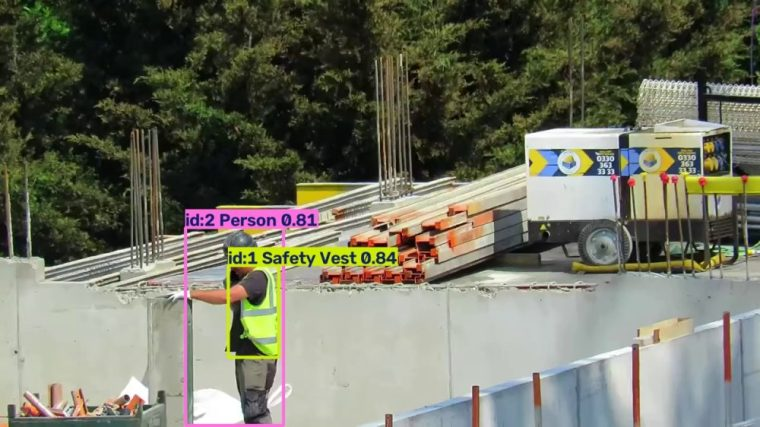

--- 02_track_f0120.jpg ---


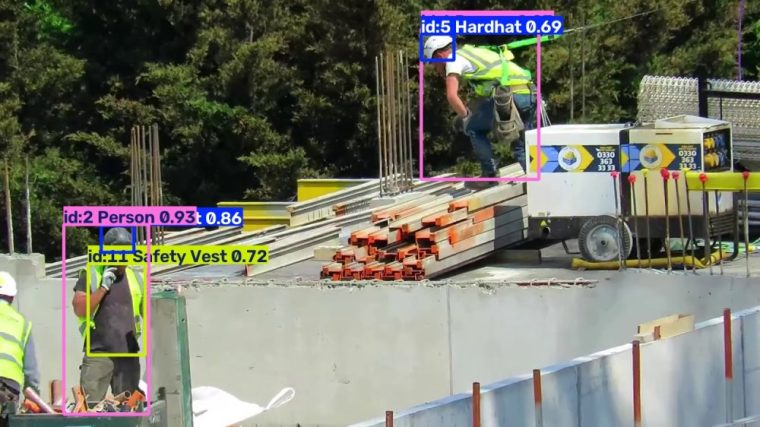

--- 02_track_f0240.jpg ---


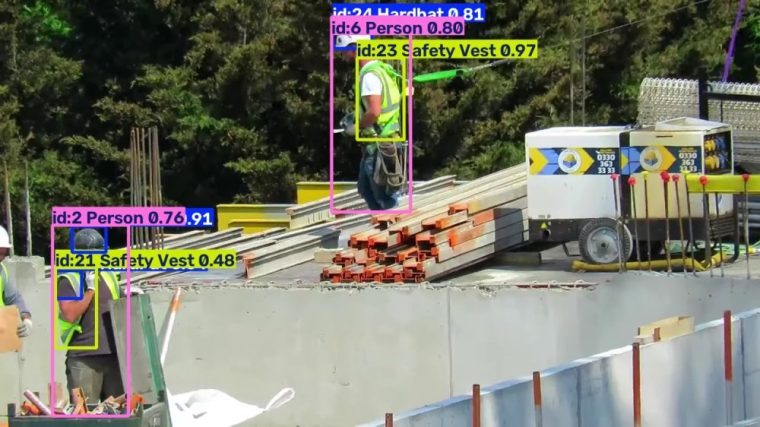

In [5]:
for name in summary["stills"]:
    shrink(OUTPUTS / name)

for name in summary["stills"][:3]:
    show(cv2.imread(str(OUTPUTS / name)), title=f"--- {name} ---")

### What the ledger found

The debounce parameters are chosen from the frame rate, not picked at random. At 15 fps:

- **open after 5 frames = 0.33 s.** Short enough to catch a worker walking briskly through frame,
  long enough that a single bad frame cannot manufacture an incident.
- **close after 15 frames = 1.0 s.** A worker passing behind a stack of material disappears for
  well under a second; without this the same event would be logged repeatedly.

,incident_id,track_id,violation,severity,first_frame,last_frame,duration_frames,duration_s,peak_conf,evidence
0,1,21,NO-Safety Vest,2,189,231,43,2.87,0.812,id021_NO_Safety_Vest_f00189.jpg
1,2,11,NO-Safety Vest,2,110,129,20,1.33,0.898,id011_NO_Safety_Vest_f00110.jpg
2,3,21,NO-Safety Vest,2,252,262,11,0.73,0.641,id021_NO_Safety_Vest_f00252.jpg



3 incident(s) logged to 02_violations.csv
3 evidence crop(s) saved
evidence: id011_NO_Safety_Vest_f00110.jpg


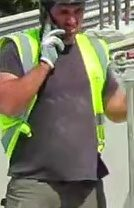

evidence: id021_NO_Safety_Vest_f00189.jpg


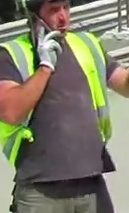

evidence: id021_NO_Safety_Vest_f00252.jpg


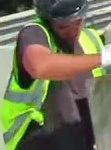

In [6]:
violations_csv = OUTPUTS / "02_violations.csv"
ledger.to_csv(violations_csv, fps=info.fps)

if ledger.incidents:
    df = pd.read_csv(violations_csv)
    display(df)
    print(f"\n{len(df)} incident(s) logged to {violations_csv.name}")
    crops = sorted((OUTPUTS / "crops").glob("*.jpg"))
    print(f"{len(crops)} evidence crop(s) saved")
    for c in crops[:4]:
        show(cv2.imread(str(c)), max_w=220, title=f"evidence: {c.name}")
else:
    print("No violation incidents logged.")
    print()
    if is_custom:
        print("Every tracked worker held a hard hat and a hi-vis vest for long enough that")
        print("no violation survived the debounce. A zero-row ledger is a real answer, not")
        print("a broken one - and the false-alarm rate is what decides whether a safety")
        print("system stays switched on.")
    else:
        print("Expected on COCO weights: there is no NO-Hardhat class to detect.")
        print("The debounce logic itself is covered by tests/test_compliance.py.")

### What the policy decision costs, on this clip

In [7]:
enforced_sum = ledger.summary(fps=info.fps)
shadow_sum = shadow.summary(fps=info.fps)

print(f"{'policy':<34}{'incidents':>10}{'workers':>9}{'exposure s':>12}")
print("-" * 65)
print(f"{'enforced (NO-Hardhat, NO-Vest)':<34}{enforced_sum['incidents']:>10}"
      f"{enforced_sum['workers_involved']:>9}{enforced_sum['total_exposure_s']:>12.1f}")
print(f"{'all three NO-* classes':<34}{shadow_sum['incidents']:>10}"
      f"{shadow_sum['workers_involved']:>9}{shadow_sum['total_exposure_s']:>12.1f}")
print()
print("by violation class:")
for label, n in sorted(shadow_sum["by_violation"].items()):
    tag = "enforced" if label in ENFORCED_CLASSES else "NOT enforced"
    print(f"  {label:<18}{n:>4}   ({tag})")

extra = shadow_sum["incidents"] - enforced_sum["incidents"]
print()
if extra > 0:
    print(f"Enforcing all three classes would add {extra} more incident(s) to the officer's")
    print("queue on 34 seconds of footage. Those alarms are correct against the dataset's")
    print("labels and wrong against site policy - masks are a demolition and silica-dust")
    print("rule, not a general one. At that rate the ledger stops being read.")
else:
    print("No difference on this clip; the two policies coincide here.")

policy                             incidents  workers  exposure s
-----------------------------------------------------------------
enforced (NO-Hardhat, NO-Vest)             3        2         4.9
all three NO-* classes                     3        2         4.9

by violation class:
  NO-Safety Vest       3   (enforced)

No difference on this clip; the two policies coincide here.


## 2. Entrance gate counting — `solutions.ObjectCounter`

A counting line is only meaningful if workers actually cross it, so the position was chosen from
the data rather than by eye. A preliminary tracking pass recorded every worker centroid, and the
candidate lines were scored by how many distinct tracks crossed them:

```
vertical   x=300  -> 3 tracks     horizontal  y=200  -> 1 track
           x=520  -> 3 tracks                 y=600  -> 3 tracks
           x=800  -> 1 track                  y=400  -> 0 tracks
```

The footage has two separate walkways — an upper one at y≈150–390 and the deck at y≈520–620.
A **vertical** gate cuts across both; any horizontal line can only ever catch one of them. `x=520`
sits where the two lanes are both active and away from the frame edges, where partially-visible
workers produce unstable tracks.

In [8]:
GATE = [(520, 100), (520, 700)]

counter = solutions.ObjectCounter(
    model=weights,
    region=GATE,
    classes=track_classes,
    conf=DEFAULT_CONF,
    show=False,
    verbose=False,
)

timeline = []


def record_counts(frame_idx, result):
    timeline.append(
        {
            "frame": frame_idx,
            "t_s": round(frame_idx / info.fps, 2),
            "in_count": result.in_count,
            "out_count": result.out_count,
            "tracks_in_frame": result.total_tracks,
        }
    )


gate_summary = run_solution(
    source=SITE_CLIP,
    solution=counter,
    output_video=OUTPUTS / "02_gate.mp4",
    still_dir=OUTPUTS,
    still_every=150,
    still_prefix="02_gate",
    on_result=record_counts,
    verbose_every=150,
)

counts = pd.DataFrame(timeline)
counts.to_csv(OUTPUTS / "02_gate_counts.csv", index=False)

print()
print(f"crossings IN  : {counts['in_count'].iloc[-1]}")
print(f"crossings OUT : {counts['out_count'].iloc[-1]}")
print(f"peak simultaneous tracks : {counts['tracks_in_frame'].max()}")
print(f"per-frame timeline written to outputs/02_gate_counts.csv ({len(counts)} rows)")
counts.tail(3)

Ultralytics Solutions:  {'source': None, 'model': 'C:\\Users\\ksama\\OneDrive\\\\projects\\OpenCode\\ppe-compliance-monitor\\models\\best.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': [(520, 100), (520, 700)], 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.1, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'botsort.yaml', 'verbose': False, 'data': 'images'}


  frame    0/510


  frame  150/510


  frame  300/510


  frame  450/510



crossings IN  : 6
crossings OUT : 6
peak simultaneous tracks : 17
per-frame timeline written to outputs/02_gate_counts.csv (510 rows)


,frame,t_s,in_count,out_count,tracks_in_frame
507,507,33.80,6,6,7
508,508,33.87,6,6,6
509,509,33.93,6,6,6


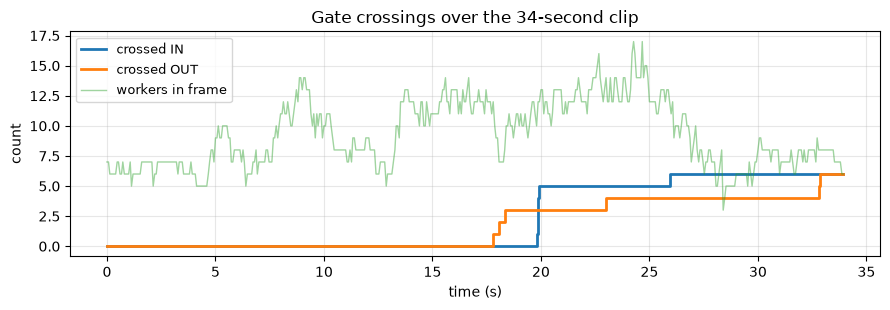

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.step(counts["t_s"], counts["in_count"], where="post", label="crossed IN", lw=2)
ax.step(counts["t_s"], counts["out_count"], where="post", label="crossed OUT", lw=2)
ax.plot(counts["t_s"], counts["tracks_in_frame"], alpha=0.45, lw=1, label="workers in frame")
ax.set_xlabel("time (s)")
ax.set_ylabel("count")
ax.set_title("Gate crossings over the 34-second clip")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUTS / "02_gate_timeline.png", dpi=110)
plt.show()

--- final gate frame (cumulative counts drawn in): 02_gate_final_f0509.jpg ---


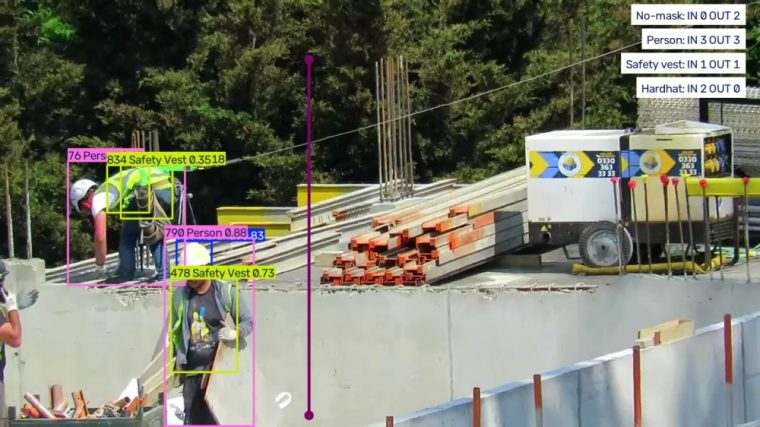

In [10]:
for name in gate_summary["stills"]:
    shrink(OUTPUTS / name)
show(cv2.imread(str(OUTPUTS / gate_summary["stills"][-1])),
     title=f"--- final gate frame (cumulative counts drawn in): {gate_summary['stills'][-1]} ---")

## 3. Activity heatmap — `solutions.Heatmap`

The counter answers *how many*. The heatmap answers *where*, by accumulating detection density
into the frame over the whole clip. On a real site this is what tells a safety manager which
routes are worn into the ground — and therefore where a barrier, a walkway or a camera should go.

Ultralytics Solutions:  {'source': None, 'model': 'C:\\Users\\ksama\\OneDrive\\\\projects\\OpenCode\\ppe-compliance-monitor\\models\\best.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 2, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.1, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'botsort.yaml', 'verbose': False, 'data': 'images'}


  frame    0/510


  frame  150/510


  frame  300/510


  frame  450/510



frames processed : 510
--- 02_heatmap_f0450.jpg ---


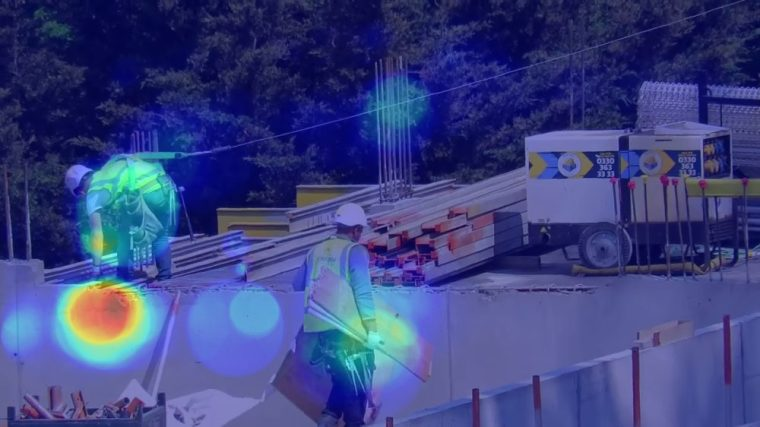

--- 02_heatmap_final_f0509.jpg ---


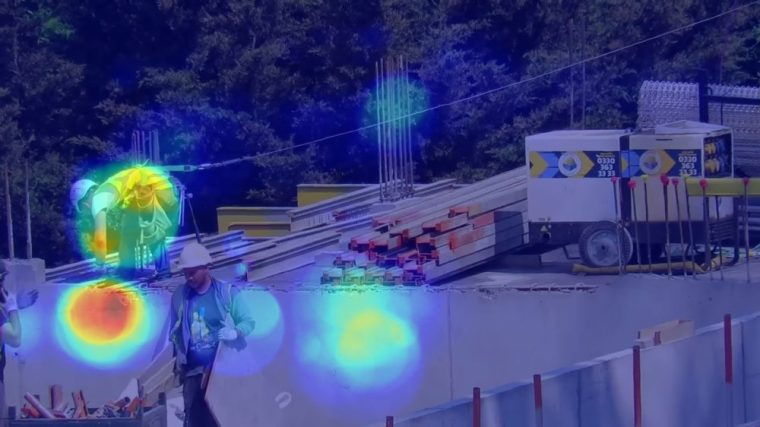

In [11]:
heatmap = solutions.Heatmap(
    model=weights,
    colormap=cv2.COLORMAP_JET,
    classes=track_classes,
    conf=DEFAULT_CONF,
    show=False,
    verbose=False,
)

heat_summary = run_solution(
    source=SITE_CLIP,
    solution=heatmap,
    output_video=OUTPUTS / "02_heatmap.mp4",
    still_dir=OUTPUTS,
    still_every=150,
    still_prefix="02_heatmap",
    verbose_every=150,
)

for name in heat_summary["stills"]:
    shrink(OUTPUTS / name)

print()
print(f"frames processed : {heat_summary['frames_processed']}")
for name in heat_summary["stills"][-2:]:
    show(cv2.imread(str(OUTPUTS / name)), title=f"--- {name} ---")

Heat accumulates along the two walkways identified earlier, brightest where workers pause to pick
up and set down material. The upper walkway and the lower deck show up as two distinct bands —
the same structure that made a vertical counting gate the right choice.

## Summary

**Deliverable 2 evidence, all produced above:**

- A real OpenCV pipeline — `VideoCapture` → per-frame processing → `VideoWriter` — over 510
  frames of genuine construction footage, not a stock demo clip
- `model.track(persist=True)` giving stable per-worker identity
- `solutions.ObjectCounter` on a gate positioned from measured trajectories
- `solutions.Heatmap` accumulating spatial activity density
- The **violation ledger**: debounced incidents, ranked by severity, with evidence crops

Artefacts: `outputs/02_track.mp4`, `02_gate.mp4`, `02_heatmap.mp4`, `02_gate_counts.csv`,
`02_violations.csv`, `02_gate_timeline.png` and sampled stills. Rendered video is gitignored as
generated output; the stills and CSVs are committed as evidence.

**Next:** [`04_training_colab.ipynb`](04_training_colab.ipynb) fine-tunes a model that actually
knows what a hard hat is, then [`03_evaluation.ipynb`](03_evaluation.ipynb) measures it and this
notebook is re-run on those weights.